# Final model · Stage 5 — the final test (opened once)

The sealed **2015 H2 test split (212,801 loans)** is opened for the first and only time and scored with the
**frozen** engine (bundle v1.0.0). The criteria were written and committed *before* this notebook ran
(`IMPLEMENTATION_PLAN.md`, commit 8c5b9ab). **Nothing is changed after this stage**; results are reported as they are.

## 1. Setup: load the frozen bundle

In [1]:
import json, sys, platform, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "engine").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev
from src.modeling import decision as dl
from src.engine import CreditRiskEngine

RESULTS = ROOT / "models" / "final" / "05_final_test" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
STAGE3 = ROOT / "models" / "final" / "03_decision_layer" / "results"
engine = CreditRiskEngine()          # verifies every bundle checksum and the scikit-learn version
manifest, policy, calibrator, booster, features = engine.manifest, engine.policy, engine.calibrator, engine.booster, engine.features
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| lightgbm", lgb.__version__)
print(f"Frozen engine: {manifest['model_name']} v{manifest['version']} | model sha256 {manifest['sha256']['final_model.txt'][:16]}")
print(f"Policy: APPROVE PD <= {policy['thresholds']['approve_max_pd']:.1%}, DECLINE PD >= {policy['thresholds']['decline_min_pd']:.1%}")

Python 3.14.6 | scikit-learn 1.9.0 | lightgbm 4.7.0
Frozen engine: M3-B-mono-nozip v1.0.0 | model sha256 2ce268265c9ca8b1
Policy: APPROVE PD <= 22.5%, DECLINE PD >= 27.5%


## 2. Open the test split
`load_split` refuses the test split unless `allow_test=True` is passed. This is the only place in the project where it is.

In [2]:
X_test, y_test_frame = ev.load_split("test", feature_columns=features + ["int_rate"], allow_test=True)
y_test = y_test_frame["target"].astype(int).to_numpy()
int_rate = X_test.pop("int_rate").to_numpy()
print(f"test: {X_test.shape}, months {y_test_frame['issue_d'].iloc[-1]}..{y_test_frame['issue_d'].iloc[0]}, default rate {y_test.mean():.2%}")

test: (212801, 146), months Jul-2015..Dec-2015, default rate 20.06%


## 3. Score every test loan with the frozen bundle

In [3]:
pd_test = dl.calibrate(booster.predict(X_test), calibrator)
term = X_test["term_months"].to_numpy()
card = ev.report_card(y_test, pd_test)
val = pd.read_parquet(STAGE3 / "f3_validation_decisions.parquet")
val_card = ev.report_card(val["target"], val["pd"])
def ece(y, p, bins=10):
    edges = np.quantile(p, np.linspace(0, 1, bins + 1)); idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, bins - 1)
    return float(sum(abs(p[idx == b].mean() - y[idx == b].mean()) * (idx == b).mean() for b in range(bins)))
metrics = pd.DataFrame({"validation (2015 H1)": {**val_card, "ece": ece(val["target"].to_numpy(), val["pd"].to_numpy())},
                        "TEST (2015 H2)": {**card, "ece": ece(y_test, pd_test)}}).loc[
    ["rows", "default_rate", "mean_pd", "calibration_gap", "roc_auc", "pr_auc", "ks", "brier", "log_loss", "ece"]]
metrics["change"] = metrics.iloc[:, 1] - metrics.iloc[:, 0]
metrics.round(4)

,validation (2015 H1),TEST (2015 H2),change
rows,162745.0000,212801.0000,50056.0000
default_rate,0.2035,0.2006,-0.0029
mean_pd,0.2035,0.1963,-0.0072
calibration_gap,0.0000,-0.0043,-0.0043
roc_auc,0.7351,0.7465,0.0114
pr_auc,0.4195,0.4336,0.0141
ks,0.3404,0.3597,0.0193
brier,0.1424,0.1388,-0.0036
log_loss,0.4458,0.4361,-0.0097
ece,0.0034,0.0059,0.0025


### Benchmark: LendingClub's own interest rate
LendingClub priced each loan from its internal grade, so its interest rate is its own risk ranking. Our model never sees it (version B).

In [4]:
lc_auc = roc_auc_score(y_test, int_rate)
print(f"ROC-AUC on test: LendingClub interest rate {lc_auc:.4f} | our engine {card['roc_auc']:.4f} | difference {card['roc_auc'] - lc_auc:+.4f}")

ROC-AUC on test: LendingClub interest rate 0.7148 | our engine 0.7465 | difference +0.0317


## 4. End-to-end check: raw CSV rows → engine
5,000 random test loans scored by `CreditRiskEngine` from their **original raw CSV rows** must give the same PDs. One pass over the raw file also collects repayment/recovery columns (for the loss back-test) and the state of every test loan.

In [5]:
LOSS_COLS = ["funded_amnt", "total_rec_prncp", "recoveries", "collection_recovery_fee", "addr_state"]
sample_ids = set(y_test_frame["id"].sample(5000, random_state=42))
test_ids = set(y_test_frame["id"])
loss_parts, raw_parts = [], []
for chunk in pd.read_csv(ROOT / "data" / "accepted_2007_to_2018Q4.csv", dtype=str, chunksize=100_000,
                         usecols=list(dict.fromkeys(["id", *engine.raw_fields, *LOSS_COLS]))):
    chunk["id"] = chunk["id"].str.strip()
    hit = chunk[chunk["id"].isin(test_ids)]
    loss_parts.append(hit[["id", *LOSS_COLS]])
    raw_parts.append(hit[hit["id"].isin(sample_ids)])
loss = pd.concat(loss_parts).set_index("id").loc[y_test_frame["id"]].reset_index()
raw = pd.concat(raw_parts).set_index("id")
pos = pd.Series(np.arange(len(y_test_frame)), index=y_test_frame["id"])
raw_scored = engine.score_batch(raw[engine.raw_fields].reset_index(drop=True))
e2e_diff = float(np.abs(raw_scored["pd"].to_numpy() - pd_test[pos.loc[raw.index].to_numpy()]).max())
print(f"{len(raw):,} raw test rows scored by the engine; max |PD difference| = {e2e_diff:.1e}")

5,000 raw test rows scored by the engine; max |PD difference| = 0.0e+00


## 5. Calibration by term and over time

In [6]:
frame = pd.DataFrame({"pd": pd_test, "target": y_test, "term": term.astype(int), "month": y_test_frame["issue_d"].to_numpy(),
                      "loan_amnt": X_test["loan_amnt"].to_numpy(), "state": loss["addr_state"].to_numpy()})
by_term = frame.groupby("term").agg(loans=("pd", "size"), mean_pd=("pd", "mean"), default_rate=("target", "mean"))
by_term["gap_pts"] = (by_term["mean_pd"] - by_term["default_rate"]) * 100
by_term["roc_auc"] = [roc_auc_score(g["target"], g["pd"]) for _, g in frame.groupby("term")]
by_month = frame.groupby("month", sort=False).agg(loans=("pd", "size"), mean_pd=("pd", "mean"), default_rate=("target", "mean"))
by_month = by_month.loc[sorted(by_month.index, key=lambda m: pd.to_datetime(m, format="%b-%Y"))]
by_month["roc_auc"] = [roc_auc_score(frame.loc[frame["month"] == m, "target"], frame.loc[frame["month"] == m, "pd"]) for m in by_month.index]
display(by_term.round(4)); by_month.round(4)

,loans,mean_pd,default_rate,gap_pts,roc_auc
term,,,,,
36,162236,0.1493,0.1471,0.2250,0.7057
60,50565,0.3471,0.3722,-2.5115,0.6933


,loans,mean_pd,default_rate,roc_auc
month,,,,
Jul-2015,41053,0.2001,0.2022,0.7464
Aug-2015,31701,0.1961,0.2000,0.7513
Sep-2015,25150,0.1982,0.2060,0.7469
Oct-2015,42986,0.1907,0.1905,0.7404
Nov-2015,32908,0.1954,0.1987,0.7483
Dec-2015,39003,0.1983,0.2086,0.7469


## 6. Risk bands, decisions and expected loss on test

In [7]:
out = dl.apply_policy(pd_test, frame["loan_amnt"], term, policy)
frame["band"], frame["decision"], frame["expected_loss"] = out["risk_band"], out["decision"], out["expected_loss"]
funded = loss["funded_amnt"].astype(float)
ead = (funded - loss["total_rec_prncp"].astype(float)).clip(lower=0)
net = (loss["recoveries"].astype(float) - loss["collection_recovery_fee"].astype(float)).clip(lower=0)
frame["realised_loss"] = np.where(y_test == 1, (ead - net).clip(lower=0), 0.0)

def summary(group):
    t = frame.groupby(group).agg(loans=("pd", "size"), mean_pd=("pd", "mean"), default_rate=("target", "mean"),
                                 funded_m=("loan_amnt", lambda s: s.sum() / 1e6), expected_loss_m=("expected_loss", lambda s: s.sum() / 1e6),
                                 realised_loss_m=("realised_loss", lambda s: s.sum() / 1e6))
    t.insert(1, "share", t["loans"] / len(frame))
    t["el_ratio"] = t["expected_loss_m"] / t["realised_loss_m"]
    return t
bands = summary("band")
decisions = summary("decision").reindex(["APPROVE", "REVIEW", "DECLINE"])
val_dec = pd.read_csv(STAGE3 / "f3_decisions.csv").set_index("decision")
decisions["validation_share"], decisions["validation_default_rate"] = val_dec["share"], val_dec["default_rate"]
display(bands.round(4)); decisions.round(4)

,loans,share,mean_pd,default_rate,funded_m,expected_loss_m,realised_loss_m,el_ratio
band,,,,,,,,
R1,20451,0.0961,0.0337,0.0296,297.7285,5.1055,3.9230,1.3014
R2,41455,0.1948,0.0754,0.0741,568.1782,21.9200,20.7673,1.0555
R3,37860,0.1779,0.1243,0.1264,501.3208,32.5676,33.3661,0.9761
R4,30119,0.1415,0.1739,0.1774,408.7952,38.2280,40.8806,0.9351
R5,40092,0.1884,0.2452,0.2495,580.1913,79.9336,89.2941,0.8952
R6,21698,0.1020,0.3449,0.3551,354.9370,72.0650,84.2545,0.8553
R7,21126,0.0993,0.5069,0.5288,396.2785,124.3604,149.8780,0.8297


,loans,share,mean_pd,default_rate,funded_m,expected_loss_m,realised_loss_m,el_ratio,validation_share,validation_default_rate
decision,,,,,,,,,,
APPROVE,142189,0.6682,0.1151,0.1160,1946.3205,117.6294,120.7361,0.9743,0.6471,0.1190
REVIEW,19871,0.0934,0.2488,0.2513,288.7961,40.2397,45.0346,0.8935,0.0976,0.2462
DECLINE,50741,0.2384,0.4033,0.4177,872.3128,216.3109,256.5931,0.8430,0.2554,0.4013


In [8]:
el_all = frame["expected_loss"].sum() / frame["realised_loss"].sum()
el_term = frame.groupby("term").apply(lambda g: g["expected_loss"].sum() / g["realised_loss"].sum(), include_groups=False)
impact = pd.DataFrame([
    {"policy": "approve everyone", "approval_rate": 1.0, "default_rate": frame["target"].mean(),
     "realised_loss_m": frame["realised_loss"].sum() / 1e6, "loss_rate": frame["realised_loss"].sum() / frame["loan_amnt"].sum()},
    *[{"policy": name, "approval_rate": m.mean(), "default_rate": frame.loc[m, "target"].mean(),
       "realised_loss_m": frame.loc[m, "realised_loss"].sum() / 1e6,
       "loss_rate": frame.loc[m, "realised_loss"].sum() / frame.loc[m, "loan_amnt"].sum()}
      for name, m in [("engine, strict (review = decline)", frame["decision"] == "APPROVE"),
                      ("engine, lenient (review = approve)", frame["decision"] != "DECLINE")]]]).set_index("policy")
impact["loss_avoided_m"] = impact["realised_loss_m"].iloc[0] - impact["realised_loss_m"]
print(f"Expected / realised loss: all {el_all:.3f} | 36m {el_term[36]:.3f} | 60m {el_term[60]:.3f}")
impact.round(4)

Expected / realised loss: all 0.886 | 36m 0.972 | 60m 0.836


,approval_rate,default_rate,realised_loss_m,loss_rate,loss_avoided_m
policy,,,,,
approve everyone,1.0000,0.2006,422.3638,0.1359,0.0000
"engine, strict (review = decline)",0.6682,0.1160,120.7361,0.0620,301.6277
"engine, lenient (review = approve)",0.7616,0.1326,165.7707,0.0742,256.5931


## 7. States (Stage 2 flagged LA, TN, OR)

In [9]:
states = frame.groupby("state").agg(loans=("pd", "size"), mean_pd=("pd", "mean"), default_rate=("target", "mean"))
states = states[states["loans"] >= 1000].copy()
states["gap_pts"] = (states["mean_pd"] - states["default_rate"]) * 100
states["flag"] = states["gap_pts"].abs() > 2
print(f"{len(states)} states with >= 1,000 test loans; gap {states['gap_pts'].min():+.2f} .. {states['gap_pts'].max():+.2f} pts; "
      f"flagged: {states.index[states['flag']].tolist()}")
states.loc[[s for s in ("LA", "TN", "OR") if s in states.index]].round(4)

37 states with >= 1,000 test loans; gap -3.82 .. +3.99 pts; flagged: ['AR', 'LA', 'MS', 'NE', 'NH', 'OK', 'OR']


,loans,mean_pd,default_rate,gap_pts,flag
state,,,,,
LA,2467,0.2103,0.2392,-2.8827,True
TN,3472,0.2223,0.2128,0.9445,False
OR,2367,0.1655,0.1343,3.1200,True


## 8. Stress check: 2016–2018 (ranking only)
Labels in this period are biased toward early outcomes, so only ROC-AUC is meaningful.

In [10]:
X_s, y_s_frame = ev.load_split("stress_2016_2018", feature_columns=features)
p_s = booster.predict(X_s.astype("float32"))
y_s = y_s_frame["target"].astype(int).to_numpy()
year = y_s_frame["issue_d"].str[-4:].to_numpy()
stress = pd.DataFrame([{"year": y, "loans": int((year == y).sum()), "default_rate": y_s[year == y].mean(),
                        "roc_auc": roc_auc_score(y_s[year == y], p_s[year == y])} for y in sorted(set(year))])
del X_s
stress.round(4)

,year,loans,default_rate,roc_auc
0,2016,293105,0.2329,0.7186
1,2017,169321,0.2313,0.7108
2,2018,56318,0.1576,0.7037


## 9. Pre-registered criteria

In [11]:
val_auc = 0.7350601950069645   # Stage 2 out-of-fold validation ROC-AUC (frozen reference)
approved_default = decisions.loc["APPROVE", "default_rate"]
criteria = pd.DataFrame([
    {"criterion": "ROC-AUC drop vs validation <= 0.02", "value": f"{val_auc - card['roc_auc']:+.4f}", "pass": val_auc - card["roc_auc"] <= 0.02},
    {"criterion": "calibration gap within +-2 pts", "value": f"{card['calibration_gap'] * 100:+.2f} pts", "pass": abs(card["calibration_gap"]) <= 0.02},
    {"criterion": "36-month gap within +-2 pts", "value": f"{by_term.loc[36, 'gap_pts']:+.2f} pts", "pass": abs(by_term.loc[36, "gap_pts"]) <= 2},
    {"criterion": "60-month gap within +-2 pts", "value": f"{by_term.loc[60, 'gap_pts']:+.2f} pts", "pass": abs(by_term.loc[60, "gap_pts"]) <= 2},
    {"criterion": "risk bands: default rate rises band to band", "value": " < ".join(f"{v:.1%}" for v in bands["default_rate"]),
     "pass": bool(bands["default_rate"].diff().dropna().gt(0).all())},
    {"criterion": "approved book default rate <= 13%", "value": f"{approved_default:.2%}", "pass": approved_default <= 0.13},
    {"criterion": "expected / realised loss in 0.85-1.15", "value": f"{el_all:.3f}", "pass": 0.85 <= el_all <= 1.15},
    {"criterion": "raw CSV -> engine matches (5,000 loans)", "value": f"{e2e_diff:.1e}", "pass": e2e_diff < 1e-9},
])
criteria["result"] = np.where(criteria["pass"], "PASS", "MISS")
print(f"{criteria['pass'].sum()} of {len(criteria)} pre-registered criteria met")
criteria[["criterion", "value", "result"]]

7 of 8 pre-registered criteria met


,criterion,value,result
0,ROC-AUC drop vs validation <= 0.02,-0.0114,PASS
1,calibration gap within +-2 pts,-0.43 pts,PASS
2,36-month gap within +-2 pts,+0.22 pts,PASS
3,60-month gap within +-2 pts,-2.51 pts,MISS
4,risk bands: default rate rises band to band,3.0% < 7.4% < 12.6% < 17.7% < 24.9% < 35.5% < ...,PASS
5,approved book default rate <= 13%,11.60%,PASS
6,expected / realised loss in 0.85-1.15,0.886,PASS
7,"raw CSV -> engine matches (5,000 loans)",0.0e+00,PASS


## 10. Charts and saving

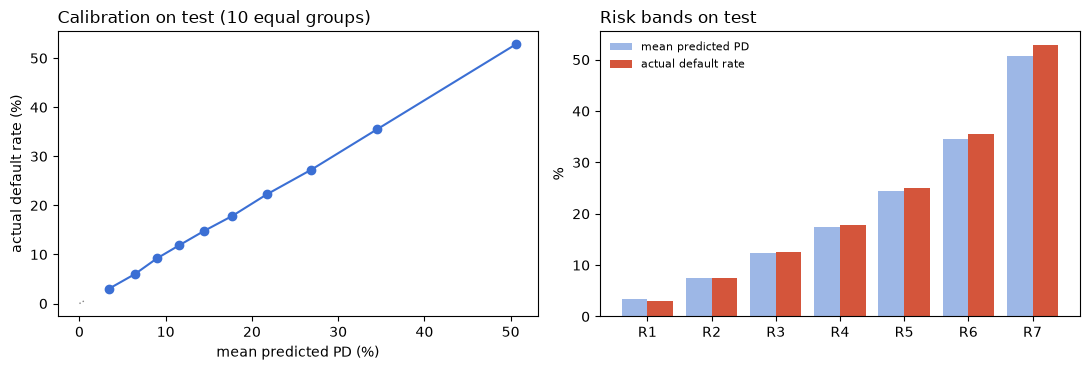

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
q = pd.qcut(pd_test, 10, labels=False, duplicates="drop")
dec = pd.DataFrame({"p": pd_test, "y": y_test, "q": q}).groupby("q").mean()
axes[0].plot([0, 0.6], [0, 0.6], ":", color="grey", lw=1)
axes[0].plot(dec["p"] * 100, dec["y"] * 100, "o-", color="#3b6fd4")
axes[0].set_xlabel("mean predicted PD (%)"); axes[0].set_ylabel("actual default rate (%)")
axes[0].set_title("Calibration on test (10 equal groups)", loc="left")
x = np.arange(len(bands))
axes[1].bar(x - 0.2, bands["mean_pd"] * 100, 0.4, color="#9db7e6", label="mean predicted PD")
axes[1].bar(x + 0.2, bands["default_rate"] * 100, 0.4, color="#d4553b", label="actual default rate")
axes[1].set_xticks(x, bands.index); axes[1].set_ylabel("%"); axes[1].legend(frameon=False, fontsize=8)
axes[1].set_title("Risk bands on test", loc="left")
fig.tight_layout(); fig.savefig(RESULTS / "f5_test_calibration.png", dpi=150); plt.show()

In [13]:
metrics.to_csv(RESULTS / "f5_metrics.csv")
by_term.to_csv(RESULTS / "f5_by_term.csv"); by_month.to_csv(RESULTS / "f5_by_month.csv")
bands.to_csv(RESULTS / "f5_bands.csv"); decisions.to_csv(RESULTS / "f5_decisions.csv"); impact.to_csv(RESULTS / "f5_business_impact.csv")
states.to_csv(RESULTS / "f5_states.csv"); stress.to_csv(RESULTS / "f5_stress.csv", index=False)
criteria.to_csv(RESULTS / "f5_criteria.csv", index=False)
summary_json = {"engine": f"{manifest['model_name']} v{manifest['version']}", "model_sha256": manifest["sha256"]["final_model.txt"],
                "test_rows": int(len(y_test)), "metrics": {k: float(v) for k, v in card.items() if isinstance(v, (int, float))},
                "ece": ece(y_test, pd_test), "lendingclub_int_rate_roc_auc": float(lc_auc),
                "expected_over_realised_loss": float(el_all), "end_to_end_max_pd_diff": e2e_diff,
                "criteria_met": int(criteria["pass"].sum()), "criteria_total": len(criteria)}
(RESULTS / "f5_summary.json").write_text(json.dumps(summary_json, indent=2), encoding="utf-8")
ev.update_leaderboard("FINAL M3-B-mono-nozip", "B", "test", card, notes="frozen bundle v1.0.0; test opened once (Stage 5)")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['f5_bands.csv', 'f5_business_impact.csv', 'f5_by_month.csv', 'f5_by_term.csv', 'f5_criteria.csv', 'f5_decisions.csv', 'f5_metrics.csv', 'f5_states.csv', 'f5_stress.csv', 'f5_summary.json', 'f5_test_calibration.png']


## 11. Conclusion

In [14]:
print(f"TEST (2015 H2, {len(y_test):,} loans): ROC-AUC {card['roc_auc']:.4f} (validation {val_auc:.4f}), KS {card['ks']:.4f}, "
      f"Brier {card['brier']:.4f}, mean PD {card['mean_pd']:.2%} vs actual {card['default_rate']:.2%}")
print(f"LendingClub's interest rate ranks the same loans at ROC-AUC {lc_auc:.4f}")
print(f"Decisions: APPROVE {decisions.loc['APPROVE', 'share']:.1%} ({approved_default:.1%} default), REVIEW {decisions.loc['REVIEW', 'share']:.1%}, "
      f"DECLINE {decisions.loc['DECLINE', 'share']:.1%} ({decisions.loc['DECLINE', 'default_rate']:.1%} default)")
print(f"Pre-registered criteria met: {criteria['pass'].sum()} of {len(criteria)}. The engine is final; next: Stage 6, the live demo.")

TEST (2015 H2, 212,801 loans): ROC-AUC 0.7465 (validation 0.7351), KS 0.3597, Brier 0.1388, mean PD 19.63% vs actual 20.06%
LendingClub's interest rate ranks the same loans at ROC-AUC 0.7148
Decisions: APPROVE 66.8% (11.6% default), REVIEW 9.3%, DECLINE 23.8% (41.8% default)
Pre-registered criteria met: 7 of 8. The engine is final; next: Stage 6, the live demo.
